In [2]:
from bcb import sgs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import ipeadatapy as ipea

In [3]:
#Dados do Banco Central (SGS)

selic = sgs.get({'selic': 4189}, start='2003-01-01', end='2025-12-31') #Taxa Selic Over Acumulada 12 meses em %.
cambio = sgs.get({'cambio': 3695}, start='2003-01-01', end='2025-12-31') # Taxa de câmbio - Livre - Dólar Americano (Compra) - Fim de Período.
IBC_br = sgs.get({'IBC_br': 24364}, start='2003-01-01', end='2025-12-31') #Com ajuste sazonal (os dados que começam mais cedo é dele)
IPCA_variacao = sgs.get({'IPCA_variacao': 433}, start='2003-01-01', end='2025-12-31')

df_bc = pd.concat([selic, cambio, IBC_br, IPCA_variacao], axis=1)
df_bc


,selic,cambio,IBC_br,IPCA_variacao
Date,,,,
2003-01-01,25.06,3.5250,70.53636,2.25
2003-02-01,25.68,3.5624,71.72228,1.57
2003-03-01,26.32,3.3523,71.37508,1.23
2003-04-01,26.32,2.8890,70.86834,0.97
2003-05-01,26.31,2.9648,70.15872,0.61
...,...,...,...,...
2025-08-01,14.90,5.4258,108.72115,-0.11
2025-09-01,14.90,5.3180,108.59808,0.48
2025-10-01,14.90,5.3837,108.69139,0.09


In [4]:
#Dados do IPEA

IPCA = ipea.timeseries('PRECOS12_IPCAGA12') #Índice de Preços ao Consumidor Amplo em % (Taxa de Variação Acumulada em 12 meses).
IPCA = IPCA.iloc[:, [-1]] #Seleciona a última coluna
IPCA.columns = ['IPCA'] #Renomeando a coluna

IPCA_Expec = ipea.timeseries('BM12_IPCAEXP1212') #Expectativa Média de Inflação (Taxa Acumulada para os Próximos Doze Meses em %)
IPCA_Expec = IPCA_Expec[['VALUE ((% a.a.))']]
IPCA_Expec.columns = ['IPCA_Expec']

salario = ipea.timeseries('GAC12_SALMINRE12') #Salário mínimo real deflacionado pelo INPC
salario = salario.iloc[:, [-1]]
salario.columns = ['salario']

horas_trabalho = ipea.timeseries('CNI12_HTRABD12') #Índice de horas trabalhadas do CNI – Proxy de Desempregro
horas_trabalho = horas_trabalho.iloc[:, [-1]]
horas_trabalho.columns = ['horas_trabalho']

tx_desemprego = ipea.timeseries('PNADC12_TDESOC12') #Taxa de desocupação das pessoas de 14 anos ou mais de idade
tx_desemprego = tx_desemprego.iloc[:, [-1]]
tx_desemprego.columns = ['tx_desemprego']

#salario #Começa em 07/1940 vai até 02/2026
#IPCA_Expec #começa em 07/2001 vai até 02/2026
#horas_trabalho #Começa em 01/1992 vai até 01/2026
#tx_desemprego #Começa em 03/2012 vai até 01/2026

consolidado_ipea = pd.concat([IPCA, IPCA_Expec, salario, horas_trabalho, tx_desemprego], axis=1) #Juntando os dados
consolidado_ipea = consolidado_ipea.loc['2003-01-01':'2025-12-01'] #Filtrando o período
df_ipea = consolidado_ipea.sort_index() #Garantindo a ordenação correta da data
df_ipea

C:\Users\Carlos Roza\AppData\Local\Temp\ipykernel_23104\187745043.py:28: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  consolidado_ipea = pd.concat([IPCA, IPCA_Expec, salario, horas_trabalho, tx_desemprego], axis=1) #Juntando os dados


,IPCA,IPCA_Expec,salario,horas_trabalho,tx_desemprego
DATE,,,,,
2003-01-01,14.47,11.7200,710.316752,95.4,NaN
2003-02-01,15.85,11.0700,700.094354,95.1,NaN
2003-03-01,16.57,9.9000,690.632893,92.0,NaN
2003-04-01,16.77,9.1800,817.478908,92.5,NaN
2003-05-01,17.24,8.2300,809.466177,92.4,NaN
...,...,...,...,...,...
2025-08-01,5.13,4.1956,1544.583003,93.9,5.6
2025-09-01,5.17,4.4689,1536.592055,94.1,5.6
2025-10-01,4.68,3.9655,1536.132231,94.5,5.4


In [5]:
dados = pd.concat([df_bc, df_ipea], axis=1)
dados

,selic,cambio,IBC_br,IPCA_variacao,IPCA,IPCA_Expec,salario,horas_trabalho,tx_desemprego
2003-01-01,25.06,3.5250,70.53636,2.25,14.47,11.7200,710.316752,95.4,NaN
2003-02-01,25.68,3.5624,71.72228,1.57,15.85,11.0700,700.094354,95.1,NaN
2003-03-01,26.32,3.3523,71.37508,1.23,16.57,9.9000,690.632893,92.0,NaN
2003-04-01,26.32,2.8890,70.86834,0.97,16.77,9.1800,817.478908,92.5,NaN
2003-05-01,26.31,2.9648,70.15872,0.61,17.24,8.2300,809.466177,92.4,NaN
...,...,...,...,...,...,...,...,...,...
2025-08-01,14.90,5.4258,108.72115,-0.11,5.13,4.1956,1544.583003,93.9,5.6
2025-09-01,14.90,5.3180,108.59808,0.48,5.17,4.4689,1536.592055,94.1,5.6
2025-10-01,14.90,5.3837,108.69139,0.09,4.68,3.9655,1536.132231,94.5,5.4
2025-11-01,14.90,5.3332,109.34730,0.18,4.46,4.0586,1535.670649,94.0,5.2


In [6]:
dados.copy() #backup

,selic,cambio,IBC_br,IPCA_variacao,IPCA,IPCA_Expec,salario,horas_trabalho,tx_desemprego
2003-01-01,25.06,3.5250,70.53636,2.25,14.47,11.7200,710.316752,95.4,NaN
2003-02-01,25.68,3.5624,71.72228,1.57,15.85,11.0700,700.094354,95.1,NaN
2003-03-01,26.32,3.3523,71.37508,1.23,16.57,9.9000,690.632893,92.0,NaN
2003-04-01,26.32,2.8890,70.86834,0.97,16.77,9.1800,817.478908,92.5,NaN
2003-05-01,26.31,2.9648,70.15872,0.61,17.24,8.2300,809.466177,92.4,NaN
...,...,...,...,...,...,...,...,...,...
2025-08-01,14.90,5.4258,108.72115,-0.11,5.13,4.1956,1544.583003,93.9,5.6
2025-09-01,14.90,5.3180,108.59808,0.48,5.17,4.4689,1536.592055,94.1,5.6
2025-10-01,14.90,5.3837,108.69139,0.09,4.68,3.9655,1536.132231,94.5,5.4
2025-11-01,14.90,5.3332,109.34730,0.18,4.46,4.0586,1535.670649,94.0,5.2


In [7]:
dados.isna().sum() #Conferindo NAs

selic               0
cambio              0
IBC_br              0
IPCA_variacao       0
IPCA                0
IPCA_Expec          0
salario             0
horas_trabalho      0
tx_desemprego     110
dtype: int64

In [8]:
#Filtro HP 

# 1. Filtro para Horas
ciclo_horas, tend_horas = sm.tsa.filters.hpfilter(dados['horas_trabalho'], lamb=14400) # O lamb=14400 é o padrão para dados mensais
dados['hiato_horas'] = ((dados['horas_trabalho'] / tend_horas) - 1) * 100 # Calculando o hiato em porcentagem

# 2. Filtro para IBC-Br (Use nomes diferentes!)
print(f"Valor atual do IBC: {dados['IBC_br'].iloc[0]}")
ciclo_ibc, tend_ibc = sm.tsa.filters.hpfilter(dados['IBC_br'], lamb=14400)

dados['hiato_IBC_br'] = ((dados['IBC_br'] / tend_ibc) - 1) * 100

dados

Valor atual do IBC: 70.53636


,selic,cambio,IBC_br,IPCA_variacao,IPCA,IPCA_Expec,salario,horas_trabalho,tx_desemprego,hiato_horas,hiato_IBC_br
2003-01-01,25.06,3.5250,70.53636,2.25,14.47,11.7200,710.316752,95.4,NaN,3.392313,1.325646
2003-02-01,25.68,3.5624,71.72228,1.57,15.85,11.0700,700.094354,95.1,NaN,2.783555,2.610822
2003-03-01,26.32,3.3523,71.37508,1.23,16.57,9.9000,690.632893,92.0,NaN,-0.840013,1.700993
2003-04-01,26.32,2.8890,70.86834,0.97,16.77,9.1800,817.478908,92.5,NaN,-0.574841,0.571723
2003-05-01,26.31,2.9648,70.15872,0.61,17.24,8.2300,809.466177,92.4,NaN,-0.955290,-0.835974
...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,14.90,5.4258,108.72115,-0.11,5.13,4.1956,1544.583003,93.9,5.6,-0.958223,-0.588591
2025-09-01,14.90,5.3180,108.59808,0.48,5.17,4.4689,1536.592055,94.1,5.6,-0.857978,-0.910801
2025-10-01,14.90,5.3837,108.69139,0.09,4.68,3.9655,1536.132231,94.5,5.4,-0.546767,-1.034268
2025-11-01,14.90,5.3332,109.34730,0.18,4.46,4.0586,1535.670649,94.0,5.2,-1.181952,-0.645849


In [9]:
dados.copy() #backup

,selic,cambio,IBC_br,IPCA_variacao,IPCA,IPCA_Expec,salario,horas_trabalho,tx_desemprego,hiato_horas,hiato_IBC_br
2003-01-01,25.06,3.5250,70.53636,2.25,14.47,11.7200,710.316752,95.4,NaN,3.392313,1.325646
2003-02-01,25.68,3.5624,71.72228,1.57,15.85,11.0700,700.094354,95.1,NaN,2.783555,2.610822
2003-03-01,26.32,3.3523,71.37508,1.23,16.57,9.9000,690.632893,92.0,NaN,-0.840013,1.700993
2003-04-01,26.32,2.8890,70.86834,0.97,16.77,9.1800,817.478908,92.5,NaN,-0.574841,0.571723
2003-05-01,26.31,2.9648,70.15872,0.61,17.24,8.2300,809.466177,92.4,NaN,-0.955290,-0.835974
...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,14.90,5.4258,108.72115,-0.11,5.13,4.1956,1544.583003,93.9,5.6,-0.958223,-0.588591
2025-09-01,14.90,5.3180,108.59808,0.48,5.17,4.4689,1536.592055,94.1,5.6,-0.857978,-0.910801
2025-10-01,14.90,5.3837,108.69139,0.09,4.68,3.9655,1536.132231,94.5,5.4,-0.546767,-1.034268
2025-11-01,14.90,5.3332,109.34730,0.18,4.46,4.0586,1535.670649,94.0,5.2,-1.181952,-0.645849


             IPCA  indice_ipca
2003-01-01  14.47   102.250000
2003-02-01  15.85   103.855325
2003-03-01  16.57   105.132745
2003-04-01  16.77   106.152533
2003-05-01  17.24   106.800064
...           ...          ...
2025-08-01   5.13   359.058272
2025-09-01   5.17   360.781752
2025-10-01   4.68   361.106455
2025-11-01   4.46   361.756447
2025-12-01   4.26   362.950243

[276 rows x 2 columns]


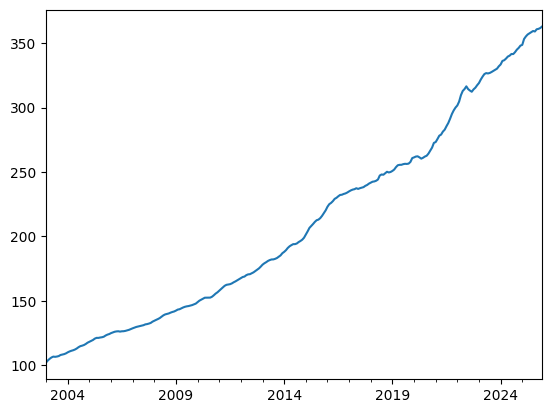

In [10]:
#Criando indice
fatores = (dados['IPCA_variacao'] / 100) + 1
dados['indice_ipca'] = 100 * fatores.cumprod()

# 3. Conferindo as primeiras linhas (o primeiro valor deve ser ~114, pois o IPCA de jan/03 era bem alto)
print(dados[['IPCA', 'indice_ipca']])
dados['indice_ipca'].plot();

In [ ]:
# Criando a dummy de crise
#dados.index = pd.to_datetime(dados.index)

c1 = (dados.index >= '2020-01-01') & (dados.index <= '2020-06-01')
c2 = (dados.index >= '2014-04-01') & (dados.index <= '2016-12-01')
c3 = (dados.index >= '2003-01-01') & (dados.index <= '2003-06-01')

dados['dummy'] = np.where(c1 | c2 | c3, 1, 0)

print(dados['dummy'].loc['2014-01-01':'2017-01-01'])

2014-01-01    0
2014-02-01    0
2014-03-01    0
2014-04-01    1
2014-05-01    1
2014-06-01    1
2014-07-01    1
2014-08-01    1
2014-09-01    1
2014-10-01    1
2014-11-01    1
2014-12-01    1
2015-01-01    1
2015-02-01    1
2015-03-01    1
2015-04-01    1
2015-05-01    1
2015-06-01    1
2015-07-01    1
2015-08-01    1
2015-09-01    1
2015-10-01    1
2015-11-01    1
2015-12-01    1
2016-01-01    1
2016-02-01    1
2016-03-01    1
2016-04-01    1
2016-05-01    1
2016-06-01    1
2016-07-01    1
2016-08-01    1
2016-09-01    1
2016-10-01    1
2016-11-01    1
2016-12-01    1
2017-01-01    0
Name: dummy, dtype: int64


In [24]:
#Exportando para Excel

dados.index = dados.index.date

dados.to_excel("dados_dissertação.xlsx", index=True)

print("Arquivo exportado com sucesso! 🎉")

Arquivo exportado com sucesso! 🎉
